In [48]:
%load_ext autoreload
%autoreload 2

In [49]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [50]:
# imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config


main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp_EDA")

df = pd.read_csv(data_csv)
cfg = { "name": "exp_EDA", "seed":42}
TARGET = "Pawpularity"
os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [51]:
df.head()

,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,0007de18844b0dbbb5e1f607da0606e0,0,1,1,1,0,0,1,0,0,0,0,0,63
1,0009c66b9439883ba2750fb825e1d7db,0,1,1,0,0,0,0,0,0,0,0,0,42
2,0013fd999caf9a3efe1352ca1b0d937e,0,1,1,1,0,0,0,0,1,1,0,0,28
3,0018df346ac9c1d8413cfcc888ca8246,0,1,1,1,0,0,0,0,0,0,0,0,15
4,001dc955e10590d3ca4673f034feeef2,0,0,0,1,0,0,1,0,0,0,0,0,72


In [52]:
df.describe()

,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
count,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000,9912.000000
mean,0.027643,0.772599,0.903955,0.861582,0.009988,0.067797,0.129338,0.049637,0.166263,0.172014,0.061239,0.070420,38.039044
std,0.163957,0.419175,0.294668,0.345356,0.099444,0.251409,0.335591,0.217204,0.372335,0.377411,0.239780,0.255866,20.591990
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.000000
50%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000


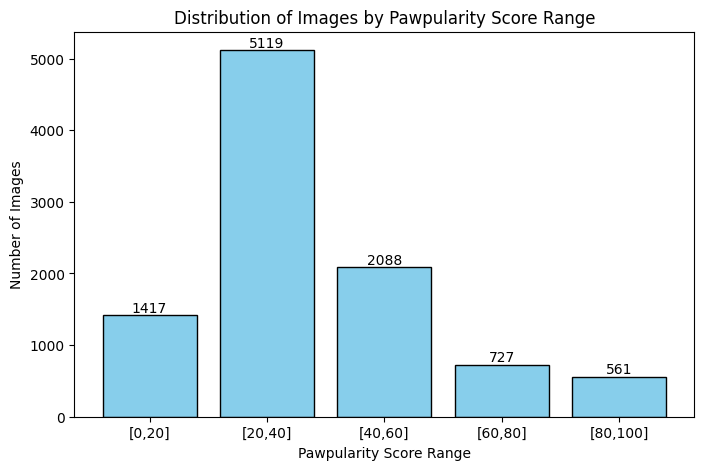

In [53]:
# Bin Pawpularity scores
bins = [0, 20, 40, 60, 80, 100]
labels = ["[0,20]", "[20,40]", "[40,60]", "[60,80]", "[80,100]"]
df['score_range'] = pd.cut(df['Pawpularity'], bins=bins, labels=labels, include_lowest=True)

score_counts = df['score_range'].value_counts().sort_index()

# Plot
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(score_counts.index, score_counts.values, color='skyblue', edgecolor='black')
ax.set_title("Distribution of Images by Pawpularity Score Range")
ax.set_xlabel("Pawpularity Score Range")
ax.set_ylabel("Number of Images")

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, str(height),
            ha='center', va='bottom', fontsize=10)

plt.show()


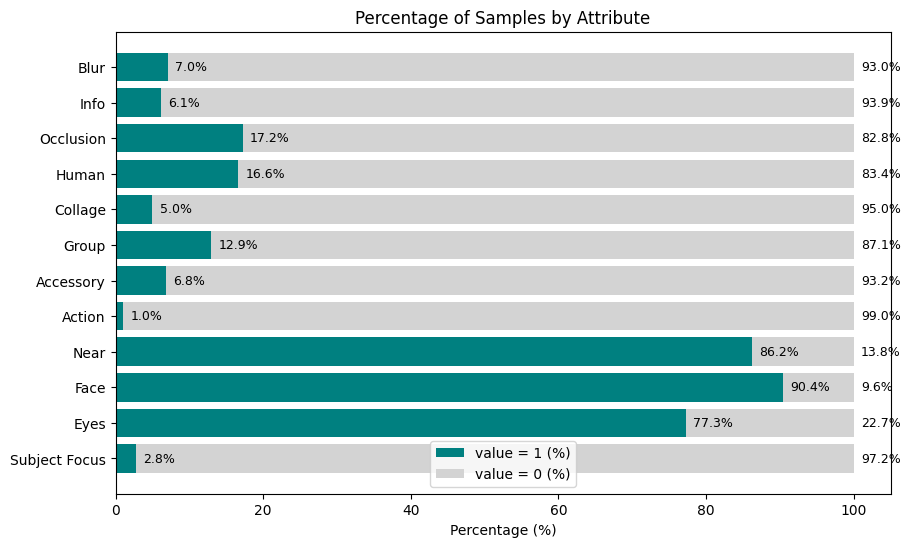

In [54]:
attributes = ["Subject Focus","Eyes","Face","Near","Action","Accessory",
              "Group","Collage","Human","Occlusion","Info","Blur"]

attr_percent = df[attributes].mean() * 100
attr_zero = 100 - attr_percent

fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.barh(attributes, attr_percent, color='teal', label="value = 1 (%)")
bars2 = ax.barh(attributes, attr_zero, left=attr_percent, color='lightgray', label="value = 0 (%)")

ax.set_title("Percentage of Samples by Attribute")
ax.set_xlabel("Percentage (%)")
ax.legend()

# Add labels for value=1 bars
for bar in bars1:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", 
            ha='left', va='center', color='black', fontsize=9)

# Add labels for value=0 bars
for bar, attr in zip(bars2, attributes):
    width = bar.get_width()
    ax.text(attr_percent[attr] + width + 1, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", 
            ha='left', va='center', color='black', fontsize=9)

plt.show()


Records loaded: 9912


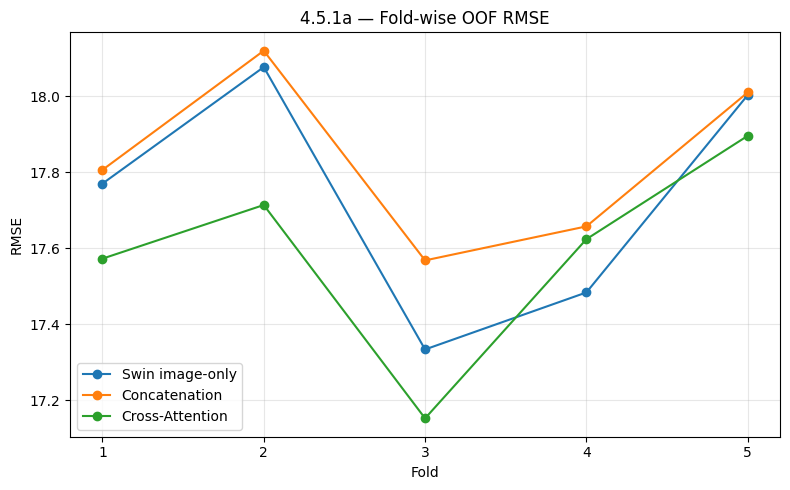


4.5.1a — Fold-wise RMSE Table
Model                      Fold1  Fold2  Fold3  Fold4  Fold5  OOF RMSE
------------------------------------------------------------------------
Swin image-only            17.7702  18.0767  17.3341  17.4841  18.0031  17.7360
Concatenation              17.8063  18.1198  17.5683  17.6578  18.0101  17.8337
Cross-Attention            17.5729  17.7140  17.1529  17.6241  17.8960  17.5937

4.5.1b — Paired Comparison: Sum of Absolute Errors per Fold
Model                      Fold1     Fold2     Fold3     Fold4     Fold5     Total
-------------------------------------------------------------------------------------
Swin image-only            25778.44  25589.61  24867.38  25074.32  25691.27  127001.02
Concatenation              26066.82  25874.98  25161.78  25337.83  25436.67  127878.08
Cross-Attention            25169.39  25568.00  25026.99  25142.35  25558.39  126465.12

Difference vs 'Swin image-only'  (negative = model is better)
Model                      Fold

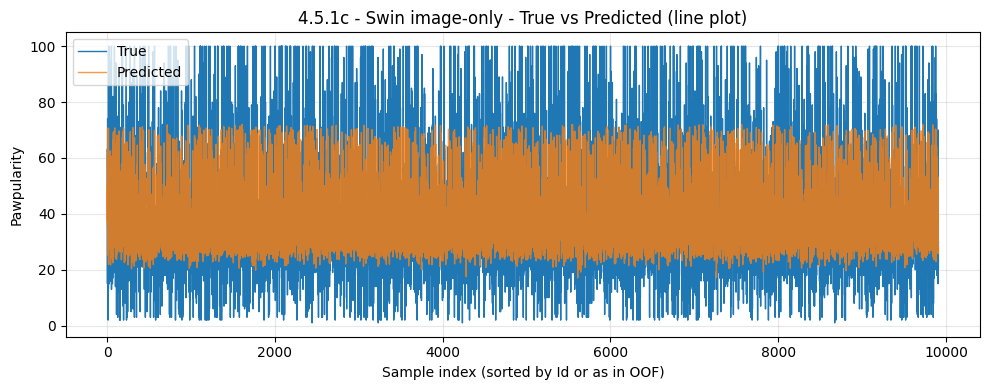

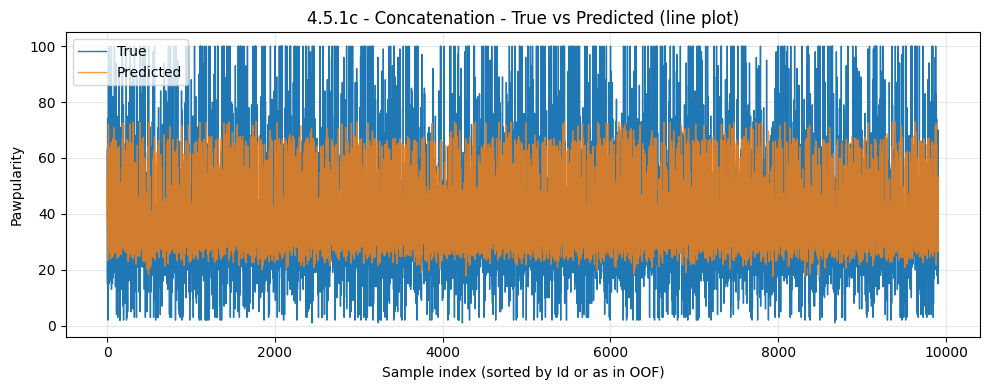

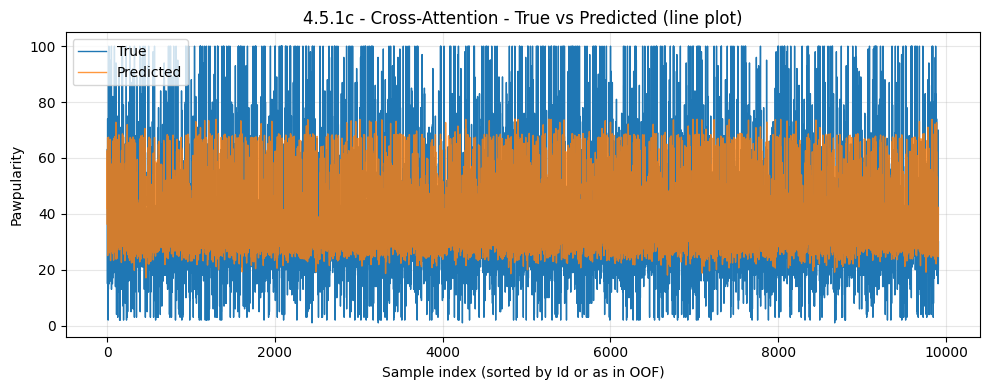


4.5.1d — Bootstrap 95% CI on OOF RMSE  (n_boot=5000)
Model                        OOF RMSE    CI lower    CI upper
--------------------------------------------------------------
Swin image-only               17.7360     17.3825     18.0805
Concatenation                 17.8337     17.5000     18.1767
Cross-Attention               17.5937     17.2651     17.9247


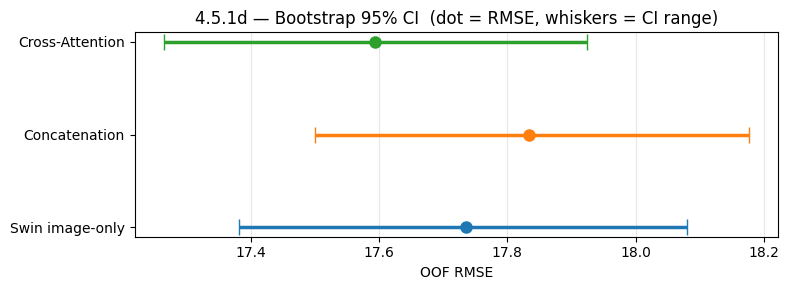

Swin image-only OOF RMSE: 17.7360
Concatenation OOF RMSE: 17.8337
Cross-Attention OOF RMSE: 17.5937


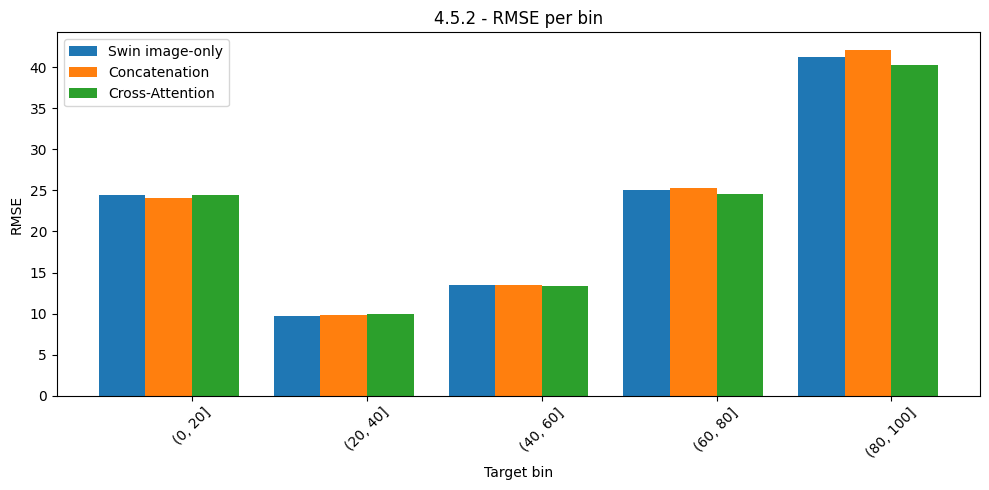


4.5.2 — Bin-wise RMSE Table
      bin  count  Swin image-only_rmse  Concatenation_rmse  Cross-Attention_rmse
  (0, 20]   1417             24.383091           24.076673             24.472875
 (20, 40]   5119              9.719382            9.782121              9.915153
 (40, 60]   2088             13.504186           13.488501             13.319313
 (60, 80]    727             25.028708           25.303170             24.507118
(80, 100]    561             41.275555           42.131492             40.256949


In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.plot import plot_foldwise_rmse, plot_oof_true_pred_lines, compare_oof_by_bins_multi

MAIN = ".."

MODELS = {
    "Swin image-only": os.path.join(MAIN, "outputs", "extra", "exp3_swin_384_strong_MSE_MLPHead", "oof_detail.csv"),
    "Concatenation":   os.path.join(MAIN, "outputs", "extra", "exp5_SwinT_StrongAug_MLPHead_mse", "oof_detail.csv"),
    "Cross-Attention": os.path.join(MAIN, "outputs", "extra", "exp13_swin_cross_attn_mse_loss_single_block_tab_transformer", "oof_detail.csv"),
}

# ── Load & merge all OOF files on Id ──────────────────────────────────────
def load_oof(path):
    d = pd.read_csv(path)
    pred_col = "oof_pred" if "oof_pred" in d.columns else "final_pred"
    return d[["Id", "fold", "ytrue"]].assign(pred=d[pred_col])

names  = list(MODELS)
merged = load_oof(MODELS[names[0]]).rename(columns={"pred": names[0]})
for name in names[1:]:
    tmp = load_oof(MODELS[name])[["Id", "pred"]].rename(columns={"pred": name})
    merged = merged.merge(tmp, on="Id", how="inner")

pred_cols = {name: name for name in names}
folds     = sorted(merged["fold"].unique())
y_true    = merged["ytrue"].values
print(f"Records loaded: {len(merged)}")

# ══════════════════════════════════════════════════════════════════
# 4.5.1a — FOLD-WISE RMSE
# ══════════════════════════════════════════════════════════════════

# Plot — one figure, all 3 models, all 5 folds on x-axis
fold_rmse_results = plot_foldwise_rmse(
    merged,
    y_col="ytrue",
    pred_cols=pred_cols,
    fold_col="fold",
    title="4.5.1a — Fold-wise OOF RMSE"
)

# Table
print("\n4.5.1a — Fold-wise RMSE Table")
print(f"{'Model':<25}" + "".join([f"  Fold{f}" for f in folds]) + "  OOF RMSE")
print("-" * 72)
oof_rmses = {}
for name in names:
    oof_rmses[name] = np.sqrt(((merged["ytrue"] - merged[name]) ** 2).mean())
    row = f"{name:<25}" + "".join([f"  {r:.4f}" for r in fold_rmse_results[name]])
    row += f"  {oof_rmses[name]:.4f}"
    print(row)

# ══════════════════════════════════════════════════════════════════
# 4.5.1b — PAIRED COMPARISON
# Sum of absolute errors per fold per model, difference vs baseline
# ══════════════════════════════════════════════════════════════════
baseline = "Swin image-only"

# Compute sum of |true - pred| per fold for each model
abs_err_sums = {}
for name in names:
    abs_err_sums[name] = []
    for f in folds:
        sub = merged[merged["fold"] == f]
        abs_err_sums[name].append(round((sub["ytrue"] - sub[name]).abs().sum(), 2))

# Table 1: raw sums
print("\n4.5.1b — Paired Comparison: Sum of Absolute Errors per Fold")
print(f"{'Model':<25}" + "".join([f"  Fold{f}   " for f in folds]) + "  Total")
print("-" * 85)
for name in names:
    total = sum(abs_err_sums[name])
    row   = f"{name:<25}" + "".join([f"  {s:>8.2f}" for s in abs_err_sums[name]])
    row  += f"  {total:>9.2f}"
    print(row)

# Table 2: difference vs baseline
print(f"\nDifference vs '{baseline}'  (negative = model is better)")
print(f"{'Model':<25}" + "".join([f"  Fold{f}   " for f in folds]) + "  Total")
print("-" * 85)
base_sums = abs_err_sums[baseline]
for name in names:
    if name == baseline:
        continue
    diffs      = [abs_err_sums[name][i] - base_sums[i] for i in range(len(folds))]
    total_diff = sum(diffs)
    row = f"{name:<25}" + "".join([f"  {d:>+8.2f}" for d in diffs])
    row += f"  {total_diff:>+9.2f}"
    print(row)

# ══════════════════════════════════════════════════════════════════
# 4.5.1c — OOF ABSOLUTE ERROR DISTRIBUTION
# 3 separate plots, one per model, using existing plot_oof_true_pred_lines
# ══════════════════════════════════════════════════════════════════
print("\n4.5.1c — OOF Error Distribution (True vs Predicted, one plot per model)")

for name in names:
    oof_df = merged[["ytrue", name]].rename(columns={name: "oof_pred"})
    plot_oof_true_pred_lines(
        oof_df,
        true_col="ytrue",
        pred_col="oof_pred",
        title_prefix=f"4.5.1c - {name}"
    )

# ══════════════════════════════════════════════════════════════════
# 4.5.1d — BOOTSTRAP 95% CI ON OOF RMSE
# ══════════════════════════════════════════════════════════════════
print("\n4.5.1d — Bootstrap 95% CI on OOF RMSE  (n_boot=5000)")
print(f"{'Model':<25}  {'OOF RMSE':>10}  {'CI lower':>10}  {'CI upper':>10}")
print("-" * 62)

rng    = np.random.default_rng(42)
n      = len(y_true)
n_boot = 5000
ci_data = {}

for name in names:
    y_pred = merged[name].values
    boot   = np.empty(n_boot)
    for i in range(n_boot):
        idx     = rng.integers(0, n, n)
        boot[i] = np.sqrt(np.mean((y_true[idx] - y_pred[idx]) ** 2))
    boot.sort()
    lo = boot[int(0.025 * n_boot)]
    hi = boot[int(0.975 * n_boot)]
    ci_data[name] = (oof_rmses[name], lo, hi)
    print(f"{name:<25}  {oof_rmses[name]:>10.4f}  {lo:>10.4f}  {hi:>10.4f}")

# Plot — horizontal error bar, one row per model
colors = ["tab:blue", "tab:orange", "tab:green"]
fig, ax = plt.subplots(figsize=(8, 3))
for i, name in enumerate(names):
    center, lo, hi = ci_data[name]
    ax.errorbar(center, i,
                xerr=[[center - lo], [hi - center]],
                fmt="o", color=colors[i], capsize=6,
                markersize=8, linewidth=2.5, label=name)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("OOF RMSE")
ax.set_title("4.5.1d — Bootstrap 95% CI  (dot = RMSE, whiskers = CI range)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 4.5.2 — BIN-WISE RMSE ACROSS PAWPULARITY RANGES
# ══════════════════════════════════════════════════════════════════
bins = [0, 20, 40, 60, 80, 100]

summary, overall = compare_oof_by_bins_multi(
    merged,
    bins=bins,
    y_col="ytrue",
    pred_cols=pred_cols,
    title_prefix="4.5.2"
)
print("\n4.5.2 — Bin-wise RMSE Table")
print(summary.to_string(index=False))